# Survey Questionnaire: Clean, Preprocess, Model, Evaluate

This notebook starts with data cleaning, then moves into preprocessing, a simple baseline model, and evaluation.

Target: predict `Task_Success` from survey responses, usability scores, and demographics.

In [ ]:
from pathlib import Path
from typing import Optional

import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
RAW_PATH = ROOT / "data" / "raw" / "survey_questionnaire_large.csv"
PROCESSED_DIR = ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

raw = pd.read_csv(RAW_PATH)
print("Raw shape:", raw.shape)
raw.head()

Raw shape: (1000, 27)


,Participant_ID,Age,Gender,Device_Type,Experience_Level,Task_Success,Completion_Time_s,SUS_Q1,SUS_Q2,SUS_Q3,...,UEQ_Attractiveness,UEQ_Efficiency,UEQ_Perspicuity,NASA_TLX_Mental,NASA_TLX_Temporal,NASA_TLX_Frustration,Trust_Score,Ease_of_Use,Willingness_to_Reuse,Attention_Check_Passed
0,P0001,28.0,F,iOS,Beginner,1.0,255.767958,5.0,4.0,4.0,...,5.0,4.0,5.0,4.863883,NaN,-3.647150,7.716290,6.774113,4.565281,0.0
1,P0002,23.0,F,Android,Intermediate,1.0,164.093073,3.0,4.0,3.0,...,5.0,6.0,NaN,7.445770,7.205746,-4.471230,7.048741,6.488260,4.576529,1.0
2,P0003,36.0,M,Desktop,Intermediate,1.0,39.923640,3.0,4.0,4.0,...,6.0,5.0,7.0,13.421865,9.567593,-3.192630,6.707821,5.860594,5.743489,1.0
3,P0004,21.0,F,iOS,Intermediate,0.0,8.817077,3.0,4.0,4.0,...,6.0,3.0,6.0,21.000000,12.944852,8.585566,2.037405,5.475659,5.293785,1.0
4,P0005,29.0,M,iOS,Beginner,1.0,173.857761,5.0,5.0,5.0,...,7.0,5.0,7.0,10.455472,7.975377,-2.220643,7.405332,6.209295,5.756259,1.0


Missing values (%) by column:
 sus_q5               2.8
sus_q1               2.5
sus_q4               2.4
experience_level     2.4
ease_of_use          2.4
nasa_tlx_temporal    2.3
sus_q10              2.3
sus_q8               2.2
sus_q6               2.2
ueq_perspicuity      2.2


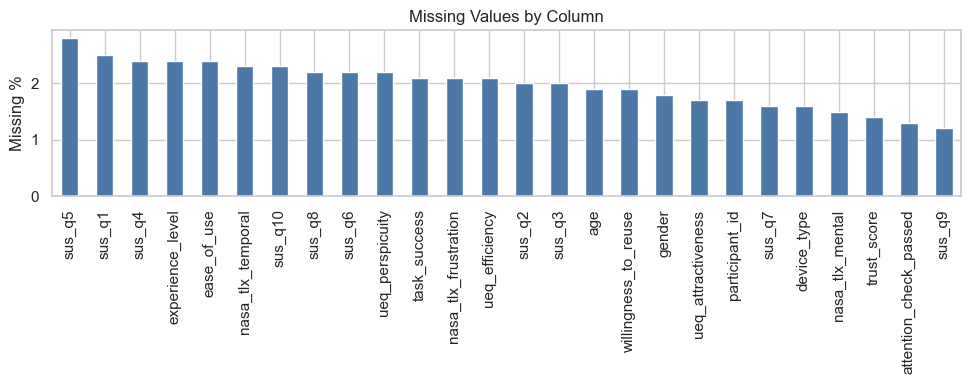

Rows before duplicate removal: 1000
Rows after duplicate removal: 1000
Saved cleaned data to /Users/chandanpai/Documents/GitHub/Quant UXR/ux-quant-analysis/data/processed/survey_questionnaire_cleaned.csv


In [10]:
def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
        .str.strip("_")
    )
    return df


def impute_numeric(series: pd.Series, low: Optional[float] = None, high: Optional[float] = None) -> pd.Series:
    numeric = pd.to_numeric(series, errors="coerce")
    if low is not None:
        numeric = numeric.mask(numeric < low)
    if high is not None:
        numeric = numeric.mask(numeric > high)
    return numeric.fillna(numeric.dropna().median())


df = standardize_columns(raw)

numeric_cols = [
    "age",
    "task_success",
    "completion_time_s",
    *[f"sus_q{i}" for i in range(1, 11)],
    "ueq_attractiveness",
    "ueq_efficiency",
    "ueq_perspicuity",
    "nasa_tlx_mental",
    "nasa_tlx_temporal",
    "nasa_tlx_frustration",
    "trust_score",
    "ease_of_use",
    "willingness_to_reuse",
    "attention_check_passed",
]

categorical_cols = ["participant_id", "gender", "device_type", "experience_level"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in categorical_cols:
    df[col] = df[col].astype("string").str.strip()

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("Missing values (%) by column:\n", missing_pct.head(10).round(2).to_string())

plt.figure(figsize=(10, 4))
missing_pct[missing_pct > 0].sort_values(ascending=False).plot(kind="bar", color="#4C78A8")
plt.title("Missing Values by Column")
plt.ylabel("Missing %")
plt.tight_layout()
plt.show()

if df["participant_id"].isna().any():
    missing_id_mask = df["participant_id"].isna()
    df.loc[missing_id_mask, "participant_id"] = [
        f"P_MISSING_{i:04d}" for i in range(1, missing_id_mask.sum() + 1)
    ]

for col in ["gender", "device_type", "experience_level"]:
    df[col] = df[col].fillna("Unknown")

for col in ["age"]:
    df[col] = impute_numeric(df[col], 18, 75).clip(18, 75)

df["completion_time_s"] = pd.to_numeric(df["completion_time_s"], errors="coerce")
df["completion_time_s"] = df["completion_time_s"].mask(df["completion_time_s"] <= 0)
df["completion_time_s"] = df["completion_time_s"].fillna(df["completion_time_s"].dropna().median())

for col in ["task_success", "attention_check_passed"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").round().clip(0, 1)
    df[col] = df[col].fillna(df[col].mode(dropna=True).iloc[0])

for col in [f"sus_q{i}" for i in range(1, 11)]:
    df[col] = impute_numeric(df[col], 1, 5).round().clip(1, 5)

for col in ["ueq_attractiveness", "ueq_efficiency", "ueq_perspicuity"]:
    df[col] = impute_numeric(df[col], 1, 7).round().clip(1, 7)

for col in ["nasa_tlx_mental", "nasa_tlx_temporal", "nasa_tlx_frustration"]:
    df[col] = impute_numeric(df[col], 0, 21).clip(0, 21)

for col in ["trust_score", "ease_of_use", "willingness_to_reuse"]:
    df[col] = impute_numeric(df[col], 1, 7).clip(1, 7)

before_drop = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Rows before duplicate removal: {before_drop}")
print(f"Rows after duplicate removal: {len(df)}")

cleaned_path = PROCESSED_DIR / "survey_questionnaire_cleaned.csv"
df.to_csv(cleaned_path, index=False)
print(f"Saved cleaned data to {cleaned_path}")

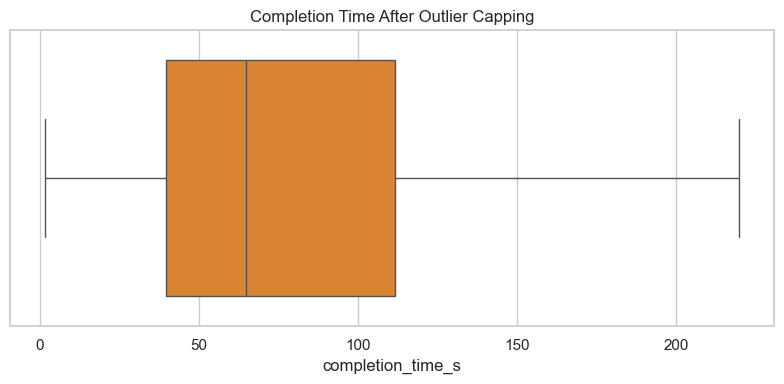

Saved analysis-ready data to /Users/chandanpai/Documents/GitHub/Quant UXR/ux-quant-analysis/data/processed/survey_questionnaire_analysis_ready.csv
Analysis-ready rows: 883


In [11]:
analysis_df = df.copy()

q1 = analysis_df["completion_time_s"].quantile(0.25)
q3 = analysis_df["completion_time_s"].quantile(0.75)
iqr = q3 - q1
lower_bound = max(0, q1 - 1.5 * iqr)
upper_bound = q3 + 1.5 * iqr
analysis_df["completion_time_s"] = analysis_df["completion_time_s"].clip(lower_bound, upper_bound)

plt.figure(figsize=(8, 4))
sns.boxplot(x=analysis_df["completion_time_s"], color="#F58518")
plt.title("Completion Time After Outlier Capping")
plt.tight_layout()
plt.show()

analysis_df["sus_score"] = (
    (analysis_df["sus_q1"] - 1)
    + (5 - analysis_df["sus_q2"])
    + (analysis_df["sus_q3"] - 1)
    + (5 - analysis_df["sus_q4"])
    + (analysis_df["sus_q5"] - 1)
    + (5 - analysis_df["sus_q6"])
    + (analysis_df["sus_q7"] - 1)
    + (5 - analysis_df["sus_q8"])
    + (analysis_df["sus_q9"] - 1)
    + (5 - analysis_df["sus_q10"])
) * 2.5

analysis_ready = analysis_df[analysis_df["attention_check_passed"] == 1].copy()
analysis_ready_path = PROCESSED_DIR / "survey_questionnaire_analysis_ready.csv"
analysis_ready.to_csv(analysis_ready_path, index=False)
print(f"Saved analysis-ready data to {analysis_ready_path}")
print("Analysis-ready rows:", len(analysis_ready))

In [12]:
target = "task_success"
feature_columns = [
    col
    for col in analysis_ready.columns
    if col not in {target, "participant_id", "attention_check_passed"}
]

categorical_features = ["gender", "device_type", "experience_level"]
numeric_features = [col for col in feature_columns if col not in categorical_features]

X = analysis_ready[feature_columns]
y = analysis_ready[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Training rows: 706
Testing rows: 177
Numeric features: 22
Categorical features: 3


In [13]:
model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("classifier", LogisticRegression(max_iter=2000)),
    ]
)

model.fit(X_train, y_train)
print("Baseline model trained.")

Baseline model trained.


accuracy     0.9322
precision    0.9427
recall       0.9801
f1           0.9610
roc_auc      0.9646

Classification report:

              precision    recall  f1-score   support

           0       0.85      0.65      0.74        26
           1       0.94      0.98      0.96       151

    accuracy                           0.93       177
   macro avg       0.90      0.82      0.85       177
weighted avg       0.93      0.93      0.93       177



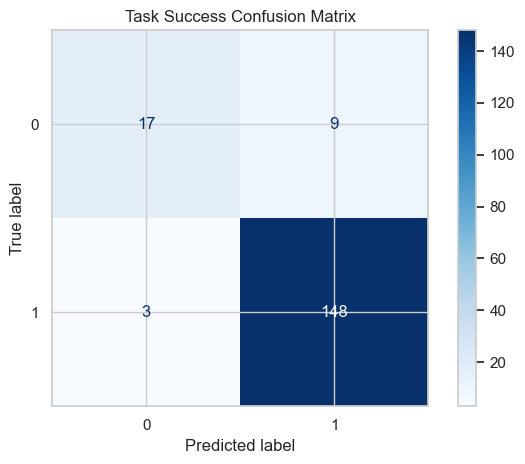

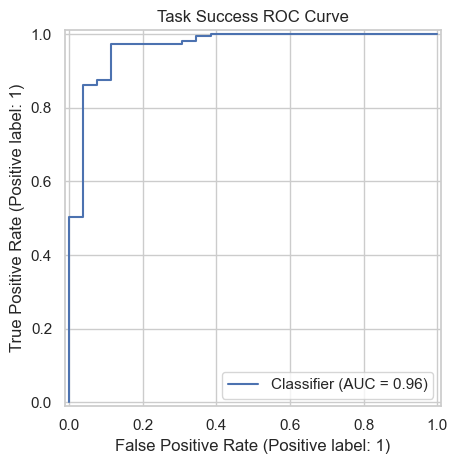

Saved metrics to /Users/chandanpai/Documents/GitHub/Quant UXR/ux-quant-analysis/data/processed/survey_task_success_metrics.csv
Saved model to /Users/chandanpai/Documents/GitHub/Quant UXR/ux-quant-analysis/data/processed/survey_task_success_logreg.pkl


In [14]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob),
}

print(pd.Series(metrics).round(4).to_string())
print("\nClassification report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("Task Success Confusion Matrix")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("Task Success ROC Curve")
plt.tight_layout()
plt.show()

metrics_path = PROCESSED_DIR / "survey_task_success_metrics.csv"
pd.Series(metrics).to_csv(metrics_path, header=["value"])
model_path = PROCESSED_DIR / "survey_task_success_logreg.pkl"
with open(model_path, "wb") as file_handle:
    pickle.dump(model, file_handle)

print(f"Saved metrics to {metrics_path}")
print(f"Saved model to {model_path}")

In [16]:
from scipy import stats

report_df = analysis_ready.copy()
completed_users = int(report_df['task_success'].sum())
failed_users = int((report_df['task_success'] == 0).sum())
total_users = len(report_df)

success_group = report_df[report_df['task_success'] == 1]
fail_group = report_df[report_df['task_success'] == 0]

report_table = pd.DataFrame({
    'metric': ['completion_rate', 'failure_rate', 'mean_sus', 'mean_trust', 'mean_ease_of_use', 'mean_frustration'],
    'value': [
        round(completed_users / total_users * 100, 1),
        round(failed_users / total_users * 100, 1),
        round(report_df['sus_score'].mean(), 2),
        round(report_df['trust_score'].mean(), 2),
        round(report_df['ease_of_use'].mean(), 2),
        round(report_df['nasa_tlx_frustration'].mean(), 2),
    ]
})
print(report_table.to_string(index=False))

comparison_metrics = ['sus_score', 'completion_time_s', 'trust_score', 'ease_of_use', 'nasa_tlx_frustration']
for metric in comparison_metrics:
    t_stat, p_value = stats.ttest_ind(success_group[metric], fail_group[metric], equal_var=False, nan_policy='omit')
    print(f'\n{metric}: t={t_stat:.3f}, p={p_value:.4g}, success_mean={success_group[metric].mean():.2f}, failure_mean={fail_group[metric].mean():.2f}')

print('\nDevice-level means for SUS, trust, ease of use, and frustration:')
for metric in ['sus_score', 'trust_score', 'ease_of_use', 'nasa_tlx_frustration']:
    print(f'\n{metric}')
    print(report_df.groupby('device_type')[metric].mean().round(2).to_string())

print('\nExperience-level means for SUS, trust, ease of use, and frustration:')
for metric in ['sus_score', 'trust_score', 'ease_of_use', 'nasa_tlx_frustration']:
    print(f'\n{metric}')
    print(report_df.groupby('experience_level')[metric].mean().round(2).to_string())

          metric  value
 completion_rate  85.20
    failure_rate  14.80
        mean_sus  50.20
      mean_trust   5.76
mean_ease_of_use   5.92
mean_frustration   4.49

sus_score: t=1.599, p=0.1115, success_mean=50.41, failure_mean=48.99

completion_time_s: t=1.894, p=0.05966, success_mean=82.97, failure_mean=73.35

trust_score: t=18.070, p=1.988e-39, success_mean=5.98, failure_mean=4.48

ease_of_use: t=15.345, p=2.385e-33, success_mean=6.07, failure_mean=5.02

nasa_tlx_frustration: t=-4.448, p=1.748e-05, success_mean=4.20, failure_mean=6.20

Device-level means for SUS, trust, ease of use, and frustration:

sus_score
device_type
Android    50.27
Desktop    49.06
Unknown    54.00
iOS        50.36

trust_score
device_type
Android    5.76
Desktop    5.78
Unknown    5.60
iOS        5.75

ease_of_use
device_type
Android    5.92
Desktop    5.93
Unknown    6.07
iOS        5.91

nasa_tlx_frustration
device_type
Android    4.57
Desktop    4.58
Unknown    4.25
iOS        4.42

Experience-level m